# AG News — Fine-Tuned DistilBERT · **Binary (Sports vs Non-Sports)**
### Model 2 (Alternative Approach) — Binary task

Pretrained / transfer-learning counterpart to the from-scratch BiLSTM, on the **same AG News
dataset**. Task: Sports (original class 2) vs Non-Sports (classes 1, 3, 4). The companion notebook
`playbook_finetune_multiclass.ipynb` handles the 4-class task with the same structure.

# Loading the dataset

## Environment Setup
Install / upgrade the libraries (Colab ships most of these, but this pins a recent `transformers`).

In [1]:
# Run once per Colab session. Safe to re-run.
!pip install -q -U "transformers>=4.40" scikit-learn
%pip install torch --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


## Import Required Libraries

In [2]:
import os, time, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_scheduler)

warnings.filterwarnings("ignore")

## Reproducibility & Device
Fine-tuning is GPU-bound: on Colab choose **Runtime > Change runtime type > GPU**.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU detected — fine-tuning will be slow. "
          "On Colab enable a GPU runtime.")

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5070 Ti Laptop GPU


## Dataset Path Setup
Point `DATA_DIR` at the folder that contains `train.csv` and `test.csv`.

- **Local / Jupyter:** put them in an `agnews` folder next to this notebook.
- **Google Colab:** after downloading the shared Drive folder, set e.g. `DATA_DIR = "/content/agnews"`.

In [4]:
DATA_DIR = "agnews"

## Load Dataset into DataFrame
The CSVs ship with a header row (`Class Index,Title,Description`). We consume it with `header=0`
and cast `Class Index` to `int` — the fix for the header-leakage bug that previously collapsed every
label to the same value.

In [5]:
def load_agnews(path):
    # header=0 consumes the real header row; `names` sets clean column names.
    # Casting to int prevents string-vs-int label comparisons later on.
    df = pd.read_csv(path, header=0, names=["Class Index", "Title", "Description"])
    df["Class Index"] = df["Class Index"].astype(int)
    return df

df_train = load_agnews(f"{DATA_DIR}/train.csv")
df_test  = load_agnews(f"{DATA_DIR}/test.csv")

print(f"Train shape: {df_train.shape}")
print(f"Test shape : {df_test.shape}")

# Guard against header-row leakage / mis-loading (expected AG News sizes).
assert df_train.shape == (120000, 3), f"Unexpected train shape: {df_train.shape}"
assert df_test.shape  == (7600, 3),   f"Unexpected test shape: {df_test.shape}"
assert set(df_train["Class Index"].unique()) == {1, 2, 3, 4}, "Class Index must be 1..4"
print("Sanity checks passed: shapes and class indices are correct.")
df_train.head(3)

Train shape: (120000, 3)
Test shape : (7600, 3)
Sanity checks passed: shapes and class indices are correct.


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...


## Dataset Overview

In [6]:
def display_dataframe_info(df, name):
    print(f"\n{'='*60}\nDATASET: {name}\n{'='*60}")
    print(f"Shape: {df.shape}")
    print("\nFirst rows:")
    print(df.head())
    print("\nColumn info:")
    df.info()
    print("\nMissing values:")
    print(df.isnull().sum())

display_dataframe_info(df_train, "Training Data")
display_dataframe_info(df_test, "Test Data")


DATASET: Training Data
Shape: (120000, 3)

First rows:
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       -------------- 

# Label Preparation
Binary mapping: original AG News class `2` (Sports) → `1`, everything else → `0`.

In [7]:
CLASS_NAMES = ["Non-Sports", "Sports"]
NUM_LABELS  = 2

def add_label(df):
    df = df.copy()
    df["label"] = (df["Class Index"].astype(int) == 2).astype(int)
    return df

df_train = add_label(df_train)
df_test  = add_label(df_test)

print("Label counts (train):", df_train["label"].value_counts().sort_index().to_dict())
print("Label counts (test) :", df_test["label"].value_counts().sort_index().to_dict())
assert set(df_train["label"].unique()) == {0, 1}

Label counts (train): {0: 90000, 1: 30000}
Label counts (test) : {0: 5700, 1: 1900}


# Exploratory Data Analysis (EDA)

## Class Distribution

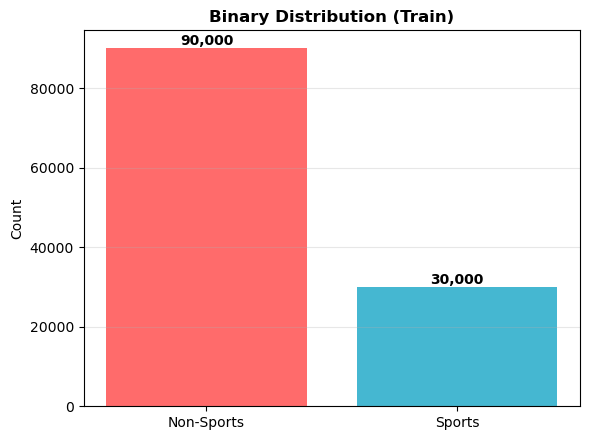

Sports is ~25% of the data — the task is imbalanced; we report macro + positive-class metrics.


In [8]:
counts = df_train["label"].value_counts().sort_index()
plt.figure(figsize=(6, 4.5))
plt.bar(CLASS_NAMES, counts.values, color=["#FF6B6B", "#45B7D1"])
plt.title("Binary Distribution (Train)", fontweight="bold")
plt.ylabel("Count"); plt.grid(axis="y", alpha=.3)
for i, v in enumerate(counts.values):
    plt.text(i, v + 800, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print("Sports is ~25% of the data — the task is imbalanced; we report macro + positive-class metrics.")

## Text Length Distribution
We combine Title + Description; lengths inform the `MAX_LEN` choice for tokenization.

Combined text length (words):
  mean 37.8 | median 37 | 95th pct 53 | max 177


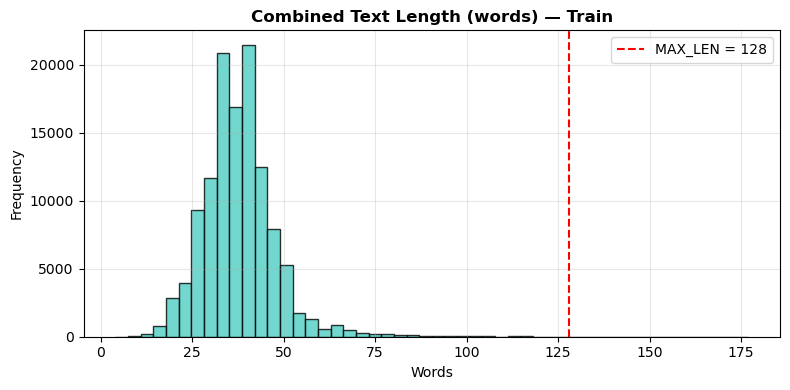

In [9]:
lengths = (df_train["Title"] + " " + df_train["Description"]).str.split().apply(len)
print("Combined text length (words):")
print(f"  mean {lengths.mean():.1f} | median {lengths.median():.0f} "
      f"| 95th pct {np.percentile(lengths, 95):.0f} | max {lengths.max()}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, color="#4ECDC4", edgecolor="black", alpha=.8)
plt.axvline(128, color="red", linestyle="--", label="MAX_LEN = 128")
plt.title("Combined Text Length (words) — Train", fontweight="bold")
plt.xlabel("Words"); plt.ylabel("Frequency"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Random Samples
Sanity-check that the labels match the content.

In [10]:
for _, row in df_train.sample(5, random_state=SEED).iterrows():
    print(f"[{CLASS_NAMES[row['label']]:10s}]  {row['Title']}")
    print(f"    {row['Description'][:110]}...\n")

[Non-Sports]  BBC set for major shake-up, claims newspaper
    London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a ...

[Non-Sports]  Marsh averts cash crunch
    Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YOR...

[Sports    ]  Jeter, Yankees Look to Take Control (AP)
    AP - Derek Jeter turned a season that started with a terrible slump into one of the best in his accomplished 1...

[Non-Sports]  Flying the Sun to Safety
    When the Genesis capsule comes back to Earth with its samples of the sun, helicopter pilots will be waiting fo...

[Non-Sports]  Stocks Seen Flat as Nortel and Oil Weigh
     NEW YORK (Reuters) - U.S. stocks were set to open near  unchanged on Thursday after a warning from technology...



# Data Preprocessing

## Text Cleaning (light — for a transformer)
DistilBERT brings its own pretrained WordPiece tokenizer, so we apply **only minimal cleaning**: fix
the HTML entities and literal backslashes AG News contains, and normalize whitespace. We deliberately
**do not lowercase or strip punctuation** — the `uncased` tokenizer handles casing, and
casing/punctuation are signal the pretrained model already uses.

In [11]:
import re

def clean_text_light(text):
    text = str(text)
    text = (text.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
                .replace("&quot;", '"').replace("&#39;", "'").replace(" #39;", "'"))
    text = text.replace("\\", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text  # no lowercasing / no punctuation removal (see note above)

def combine(df):
    df = df.copy()
    df["text"] = (df["Title"] + ". " + df["Description"]).apply(clean_text_light)
    return df

df_train = combine(df_train)
df_test  = combine(df_test)
print("Sample cleaned text:\n ", df_train["text"].iloc[0][:160])

Sample cleaned text:
  Wall St. Bears Claw Back Into the Black (Reuters). Reuters - Short-sellers, Wall Street's dwindling band of ultra-cynics, are seeing green again.


# Tokenization (Pretrained DistilBERT Tokenizer)

In [12]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 128
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer '{MODEL_NAME}' (vocab size {tokenizer.vocab_size:,})")

class AGNewsDataset(Dataset):
    "Tokenizes text on the fly and attaches integer labels."
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], truncation=True, padding="max_length",
                       max_length=self.max_len, return_tensors="pt")
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

Loaded tokenizer 'distilbert-base-uncased' (vocab size 30,522)


## Train / Validation / Test Split
We hold out a **stratified validation** set from the training data and keep the official 7,600-row
test set untouched.

Fine-tuning the full 120k for several epochs is feasible on a Colab GPU but slow (~10 min/epoch).
`USE_SUBSET` defaults to a 20k sample for a practical runtime; set it to `False` to train on
everything.

In [13]:
VAL_FRACTION = 0.1

train_idx, val_idx = train_test_split(
    np.arange(len(df_train)),
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=df_train["label"],
)

# --- Practical runtime knob ---
USE_SUBSET        = True     # set False to fine-tune on the FULL dataset
SUBSET_TRAIN_SIZE = 20000
SUBSET_VAL_SIZE   = 4000
# ------------------------------

rng = np.random.default_rng(SEED)
if USE_SUBSET:
    train_idx = rng.permutation(train_idx)[:SUBSET_TRAIN_SIZE]
    val_idx   = rng.permutation(val_idx)[:SUBSET_VAL_SIZE]

texts_train = df_train["text"].values[train_idx]
texts_val   = df_train["text"].values[val_idx]
texts_test  = df_test["text"].values

y_train = df_train["label"].values[train_idx]
y_val   = df_train["label"].values[val_idx]
y_test  = df_test["label"].values

print(f"Train: {len(texts_train):,} | Val: {len(texts_val):,} | Test: {len(texts_test):,}")
print("Train label dist:", np.bincount(y_train).tolist())
assert len(texts_train) == len(y_train)

Train: 20,000 | Val: 4,000 | Test: 7,600
Train label dist: [14938, 5062]


# Training & Evaluation Utilities

In [14]:
EPOCHS        = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1

def make_loader(texts, labels, shuffle):
    ds = AGNewsDataset(texts, labels, tokenizer, MAX_LEN)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, preds, labels = 0.0, [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        out = model(**batch)
        total_loss += out.loss.item() * batch["labels"].size(0)
        preds.extend(out.logits.argmax(-1).cpu().numpy())
        labels.extend(batch["labels"].cpu().numpy())
    return total_loss / len(labels), accuracy_score(labels, preds), np.array(preds), np.array(labels)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def fine_tune(task_name, num_labels, y_train, y_val):
    "Fine-tune a fresh DistilBERT. Returns (model, history, elapsed_seconds)."
    set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels).to(device)

    train_loader = make_loader(texts_train, y_train, shuffle=True)
    val_loader   = make_loader(texts_val,   y_val,   shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    num_training_steps = EPOCHS * len(train_loader)
    scheduler = get_scheduler("linear", optimizer=optimizer,
                              num_warmup_steps=int(WARMUP_RATIO * num_training_steps),
                              num_training_steps=num_training_steps)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    print(f"\n=== Fine-tuning [{task_name}] — {num_labels} classes, {EPOCHS} epochs ===")
    print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>8}")
    print("-" * 55)

    start = time.time()
    for epoch in range(1, EPOCHS + 1):
        model.train()
        run_loss, run_correct, run_total = 0.0, 0, 0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            run_loss    += loss.item() * batch["labels"].size(0)
            run_correct += (out.logits.argmax(-1) == batch["labels"]).sum().item()
            run_total   += batch["labels"].size(0)
        tr_loss, tr_acc = run_loss / run_total, run_correct / run_total
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss);   history["val_acc"].append(vl_acc)
        print(f"{epoch:>6}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>8.4f}  {vl_acc:>8.4f}")
    elapsed = time.time() - start
    print(f"Training time: {elapsed/60:.1f} min")
    return model, history, elapsed

def plot_curves(history, title):
    ep = range(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(ep, history["train_loss"], "o-", label="Train")
    ax[0].plot(ep, history["val_loss"],   "s-", label="Validation")
    ax[0].set_title(f"{title} — Loss", fontweight="bold")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep, history["train_acc"], "o-", label="Train")
    ax[1].plot(ep, history["val_acc"],   "s-", label="Validation")
    ax[1].set_title(f"{title} — Accuracy", fontweight="bold")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

def plot_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    n = len(class_names)
    fig, ax = plt.subplots(figsize=(1.4 * n + 3, 1.2 * n + 3))
    im = ax.imshow(cm, cmap=plt.cm.Blues); plt.colorbar(im, ax=ax)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha="right"); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title, fontweight="bold")
    thr = cm.max() / 2.0
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > thr else "black", fontweight="bold")
    plt.tight_layout(); plt.show()

# Fine-Tuning — Binary (Sports vs Non-Sports)

## Training

In [15]:
model, history, train_time = fine_tune(
    "Binary (Sports vs rest)", num_labels=NUM_LABELS, y_train=y_train, y_val=y_val)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== Fine-tuning [Binary (Sports vs rest)] — 2 classes, 3 epochs ===
 Epoch  Train Loss  Train Acc  Val Loss   Val Acc
-------------------------------------------------------
     1      0.1213     0.9533    0.0366    0.9902
     2      0.0276     0.9923    0.0332    0.9910
     3      0.0113     0.9974    0.0329    0.9932
Training time: 3.9 min


## Training Curves

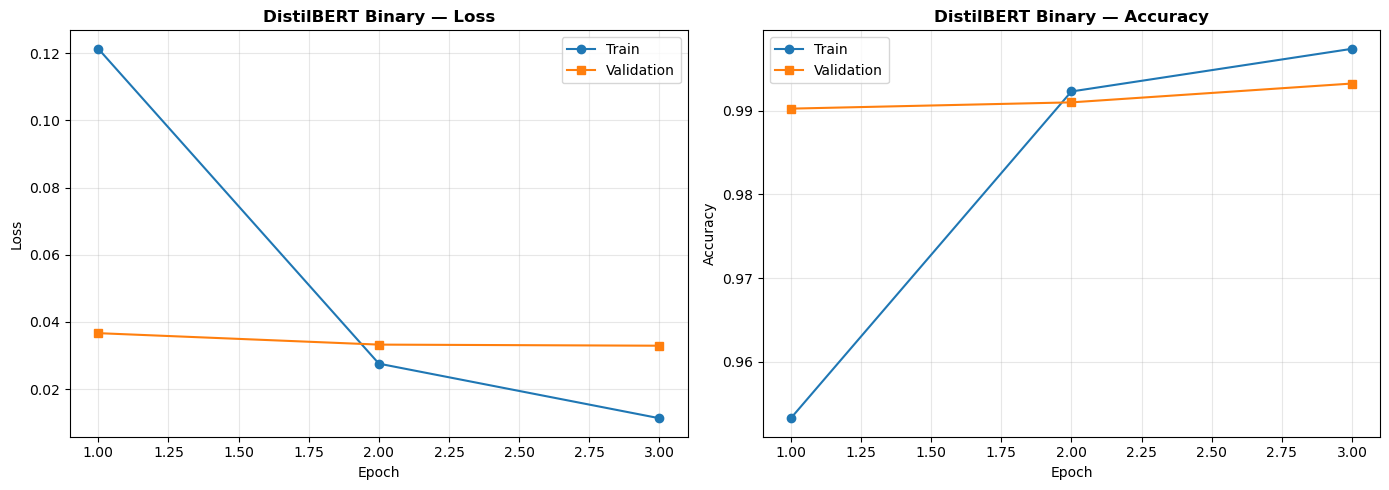

In [16]:
plot_curves(history, "DistilBERT Binary")

## Evaluation (Test Set)

In [17]:
test_loader = make_loader(texts_test, y_test, shuffle=False)
_, _, preds, labels = evaluate(model, test_loader)

acc      = accuracy_score(labels, preds)
prec_pos = precision_score(labels, preds, pos_label=1)
rec_pos  = recall_score(labels, preds, pos_label=1)
f1_pos   = f1_score(labels, preds, pos_label=1)
prec_mac = precision_score(labels, preds, average="macro")
rec_mac  = recall_score(labels, preds, average="macro")
f1_mac   = f1_score(labels, preds, average="macro")

print(f"Test Accuracy      : {acc:.4f}")
print(f"Precision (Sports) : {prec_pos:.4f}")
print(f"Recall    (Sports) : {rec_pos:.4f}")
print(f"F1        (Sports) : {f1_pos:.4f}")
print(f"Macro F1           : {f1_mac:.4f}\n")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

# Macro metrics stored for an apples-to-apples comparison with the multiclass notebook.
result = {"model": "DistilBERT (fine-tuned)", "task": "Binary (2)",
          "accuracy": acc, "precision": prec_mac, "recall": rec_mac, "f1": f1_mac,
          "train_time_s": train_time, "params": count_trainable(model)}

Test Accuracy      : 0.9911
Precision (Sports) : 0.9826
Recall    (Sports) : 0.9816
F1        (Sports) : 0.9821
Macro F1           : 0.9881

              precision    recall  f1-score   support

  Non-Sports       0.99      0.99      0.99      5700
      Sports       0.98      0.98      0.98      1900

    accuracy                           0.99      7600
   macro avg       0.99      0.99      0.99      7600
weighted avg       0.99      0.99      0.99      7600



## Confusion Matrix

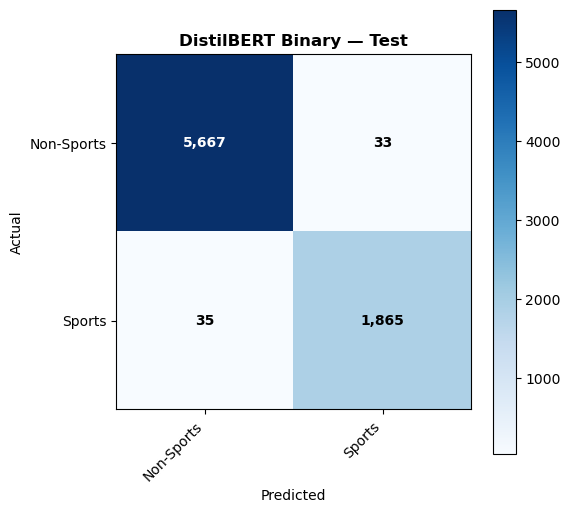

In [18]:
plot_confusion(labels, preds, CLASS_NAMES, "DistilBERT Binary — Test")

## Save Checkpoint

In [19]:
save_dir = "distilbert_agnews_binary"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f"Saved binary model + tokenizer to ./{save_dir}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved binary model + tokenizer to ./distilbert_agnews_binary/


# Comparison (Model 1 vs Model 2 — Binary)
Paste your from-scratch **BiLSTM binary** numbers into `scratch` to complete the table. Table metrics
are macro-averaged (positive-class metrics are printed in the evaluation cell above).

In [20]:
scratch = {"model": "BiLSTM (scratch)", "task": "Binary (2)",
           "accuracy": None, "precision": None, "recall": None, "f1": None,
           "train_time_s": None, "params": None}

comp = pd.DataFrame({"Scratch Binary": scratch,
                     "FineTune Binary": result}).T
comp = comp[["model", "task", "accuracy", "precision", "recall", "f1",
             "train_time_s", "params"]]
for c in ["accuracy", "precision", "recall", "f1"]:
    comp[c] = pd.to_numeric(comp[c], errors="coerce").round(4)
comp.to_csv("comparison_binary.csv")
print("Saved comparison_binary.csv")
comp

Saved comparison_binary.csv


,model,task,accuracy,precision,recall,f1,train_time_s,params
Scratch Binary,BiLSTM (scratch),Binary (2),NaN,NaN,NaN,NaN,None,None
FineTune Binary,DistilBERT (fine-tuned),Binary (2),0.9911,0.9882,0.9879,0.9881,234.0816,66955010


# Notes for the Report (Binary)

## Model & Design Choices
- **DistilBERT (`distilbert-base-uncased`)** as Model 2: a strong, lightweight transfer-learning
  baseline (~97% of BERT-base accuracy, ~40% fewer parameters).
- **Minimal cleaning** (HTML/whitespace only): the pretrained tokenizer expects natural text.
- **Manual training loop** mirrors the scratch notebook's `run_epoch` and yields per-epoch curves.
- **Stratified split** keeps the 25% Sports / 75% Non-Sports ratio in train and validation; the
  official test set is held out for final evaluation.

## Hyperparameters
| Hyperparameter | Value |
|---|---|
| Base model | `distilbert-base-uncased` |
| Max sequence length | 128 |
| Batch size | 32 |
| Optimizer | AdamW |
| Learning rate | 2e-5 |
| Weight decay | 0.01 |
| LR schedule | linear, 10% warmup |
| Gradient clipping | max-norm 1.0 |
| Epochs | 3 |
| Seed | 42 |
| Training subset | 20,000 (set `USE_SUBSET=False` for full 120k) |

## Comparison Notes
- The binary Sports task is comparatively easy, so both the scratch BiLSTM and the fine-tuned
  DistilBERT are expected to score highly — the margin between them is usually smaller here than on
  the 4-class task.
- Because the task is imbalanced (~25% positive), report **macro F1** and the **Sports-class**
  precision/recall/F1, not accuracy alone.
- Fairness: identical dataset, split protocol, and metric definitions across both models.